# Módulo 10 atividade 1

Uma instituição financeira quer conhecer melhor o perfil de renda de seus novos clientes para diversos fins, por exemplo, melhor dimensionar o limite de cartões de crédito dos novos clientes, sem necessariamente solicitar olerites ou documentações que impactem na experiência do seu cliente.

Para isto, conduziu um estudo com alguns clientes, comprovando suas rendas através de olerites e outros documentos, e pretende construir um modelo preditivo para esta renda com base em algumas variáveis que já possui em seu banco de dados.

As variáveis são intuitivas - note que há uma variável 'index' que é um identificador do cliente e que em geral o ```read_csv``` do pandas coloca também uma variável sequencial.

Estes dados estão no arquivo ```previsao_de_renda.csv```. Carregue-o em um *dataframe*.

1) Avalie a estrutura de correlação das variáveis quantitativas através de um gráfico de "matriz de dispersão" e através da avaliação gráfica da matriz de correlações. Veja se você identifica algum padrão interessante ou que te faça sentido.

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Carregar os dados no dataframe
df = pd.read_csv('previsao_de_renda.csv')

# Visualizar as primeiras linhas do dataframe para conferir
print(df.head())

   Unnamed: 0    data_ref  index sexo  posse_de_veiculo  posse_de_imovel  \
0           0  2015-01-01   8682    F             False             True   
1           1  2015-01-01  12830    M              True             True   
2           2  2015-01-01   2885    M              True             True   
3           3  2015-01-01  16168    F              True            False   
4           4  2015-01-01  12438    M             False            False   

   qtd_filhos   tipo_renda           educacao estado_civil tipo_residencia  \
0           1  Assalariado         Secundário       Casado            Casa   
1           0   Empresário         Secundário       Casado            Casa   
2           2  Assalariado  Superior completo       Casado            Casa   
3           0   Empresário         Secundário       Casado            Casa   
4           0  Assalariado         Secundário       Casado            Casa   

   idade  tempo_emprego  qt_pessoas_residencia    mau    renda  
0     36 

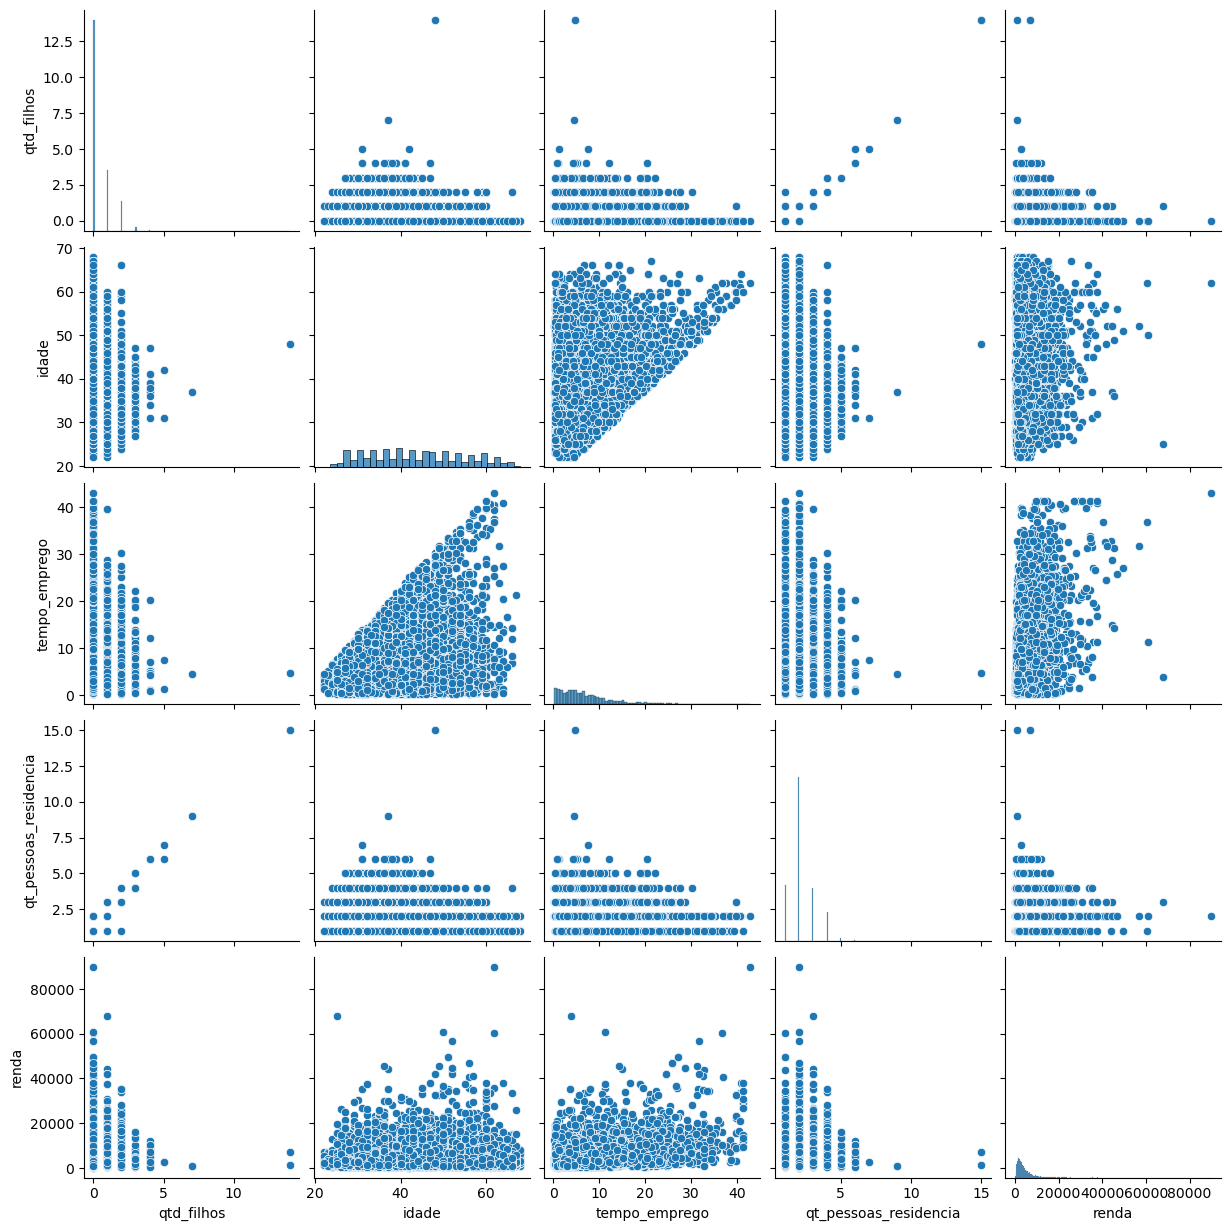

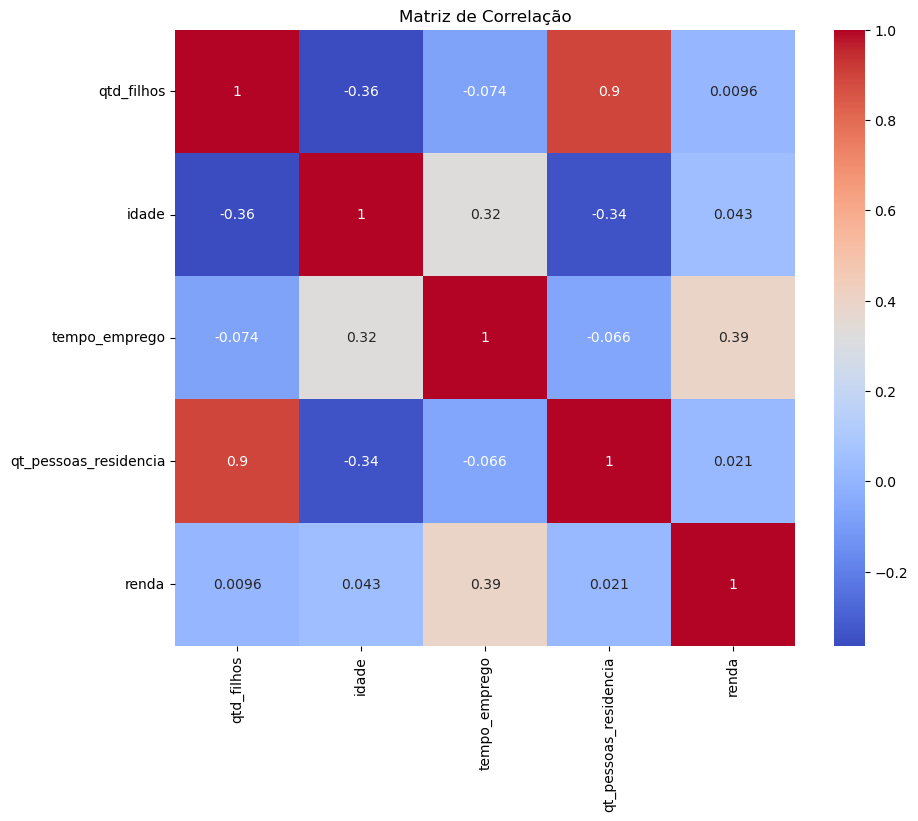

In [31]:
# Selecionar as colunas específicas para a correlação
colunas_para_correlacao = ['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'renda']  # Substitua pelos nomes das colunas desejadas
df_corr = df[colunas_para_correlacao]

# Matriz de dispersão (pairplot)
sns.pairplot(df_corr)
plt.show()

# Matriz de correlação
correlation_matrix = df_corr.corr()

# Plotar a matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

Após selecionar apenas as variáveis quantitativas, foi observado que as maiores correlações foram uma correlação positia entre tempo de emprego e renda, bem como uma correlação negativa entre idade e quantidade de filhos. 

2) Avalie um gráfico de dispersão (*scatterplot*) específico para as duas variáveis mais correlacionadas com *renda*.

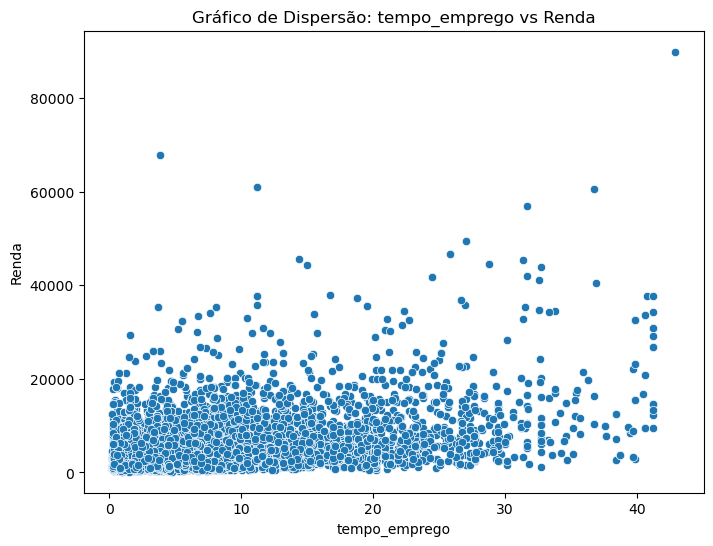

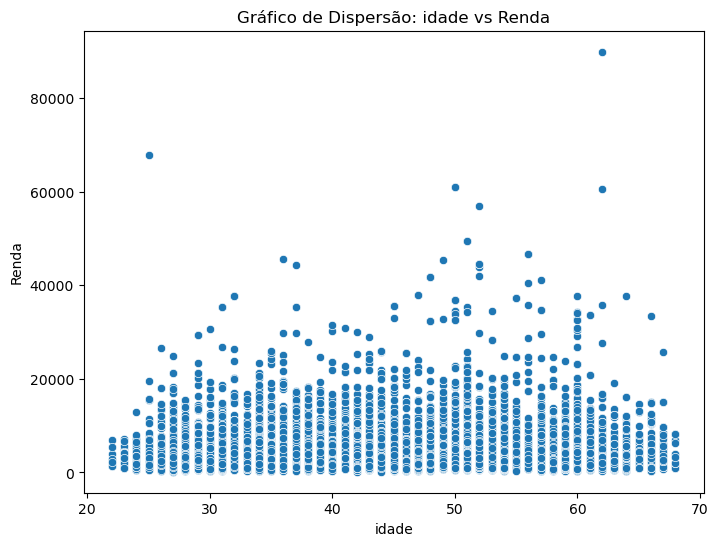

As duas variáveis mais correlacionadas com renda são: tempo_emprego e idade


In [33]:
# Calcular a matriz de correlação
correlation_matrix = df_corr.corr()

# Identificar as duas variáveis mais correlacionadas com 'renda'
top_correlations = correlation_matrix['renda'].abs().sort_values(ascending=False)
top_variables = top_correlations.index[1:3]  # As duas variáveis mais correlacionadas (excluindo 'renda' própria)

# Gráfico de dispersão para as duas variáveis mais correlacionadas com 'renda'
for var in top_variables:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=var, y='renda')
    plt.title(f'Gráfico de Dispersão: {var} vs Renda')
    plt.xlabel(var)
    plt.ylabel('Renda')
    plt.show()

# Mostrar as duas variáveis mais correlacionadas
print(f"As duas variáveis mais correlacionadas com renda são: {top_variables[0]} e {top_variables[1]}")

As variáveis com maior correlação para a variável renda foram tempo de emprego e a idade

3) Na sua opinião, há outliers na variável renda?

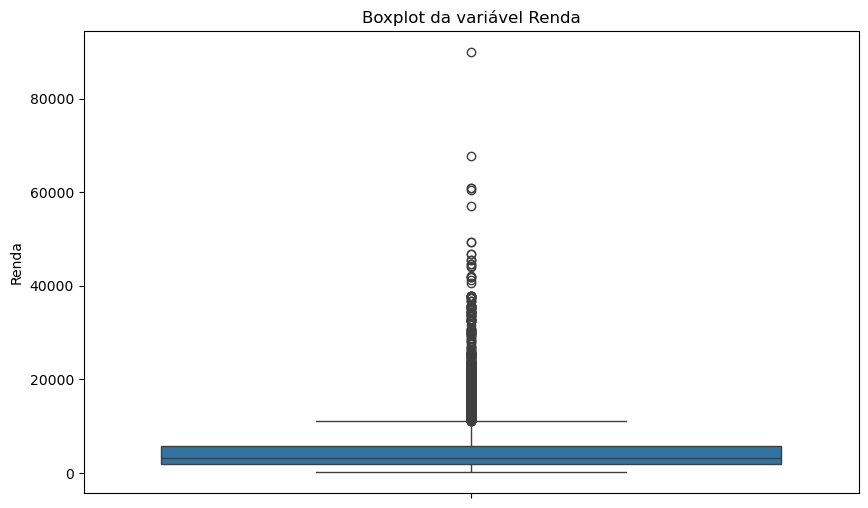

In [35]:
# Criar o boxplot da variável 'renda'
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_corr['renda'])
plt.title('Boxplot da variável Renda')
plt.ylabel('Renda')
plt.show()

Sim, com base no boxplot é possível observar que há dados que excedem os intervalos interquartis.

4) Calcule o logaritmo da variável renda e repita a sequência de análise

C:\Users\tiago\AppData\Local\Temp\ipykernel_9868\1058038950.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_corr['log_renda'] = np.log(df_corr['renda'])


   qtd_filhos  idade  tempo_emprego  qt_pessoas_residencia    renda  log_renda
0           1     36       3.575342                    3.0  3369.24   8.122442
1           0     42       0.860274                    2.0  6096.14   8.715411
2           2     31       8.065753                    4.0  5658.98   8.640999
3           0     50       1.208219                    2.0  7246.69   8.888300
4           0     52      13.873973                    2.0  4017.37   8.298383


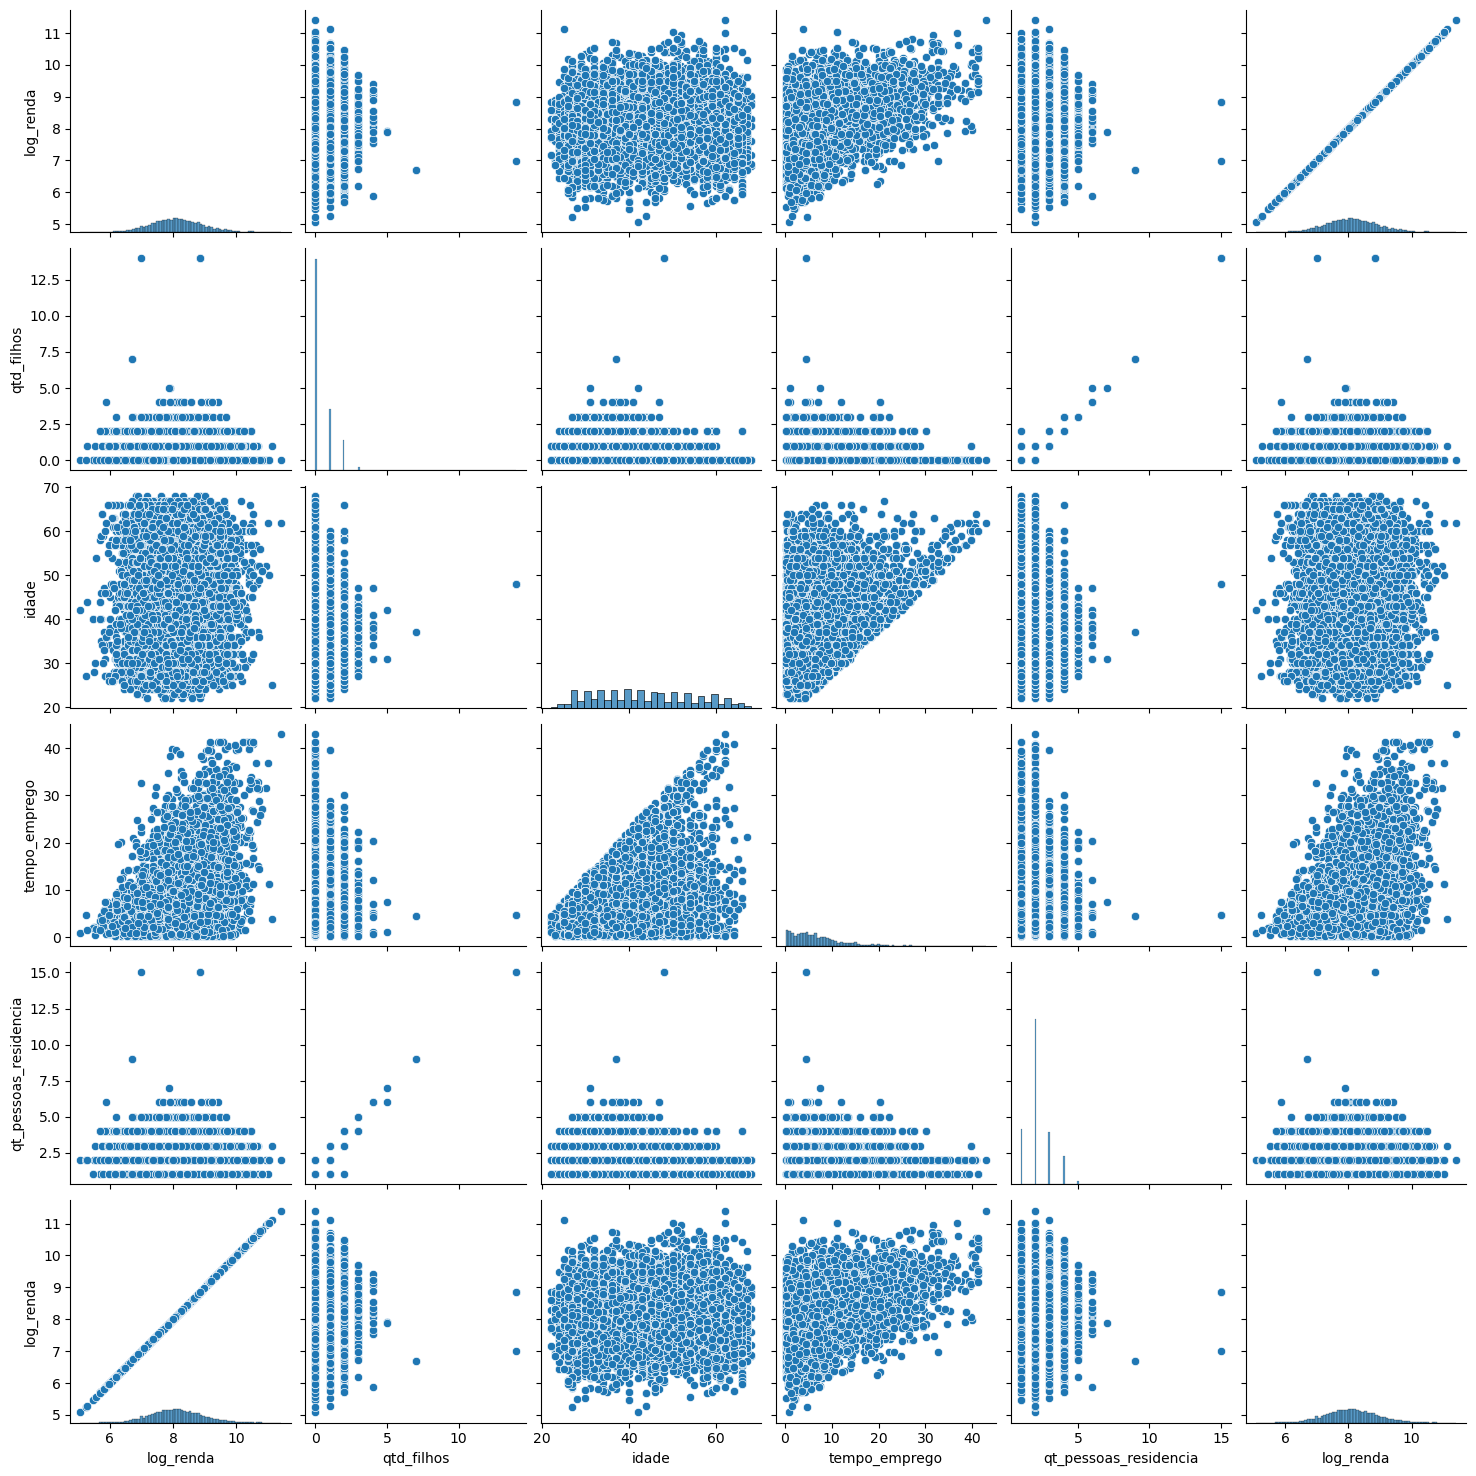

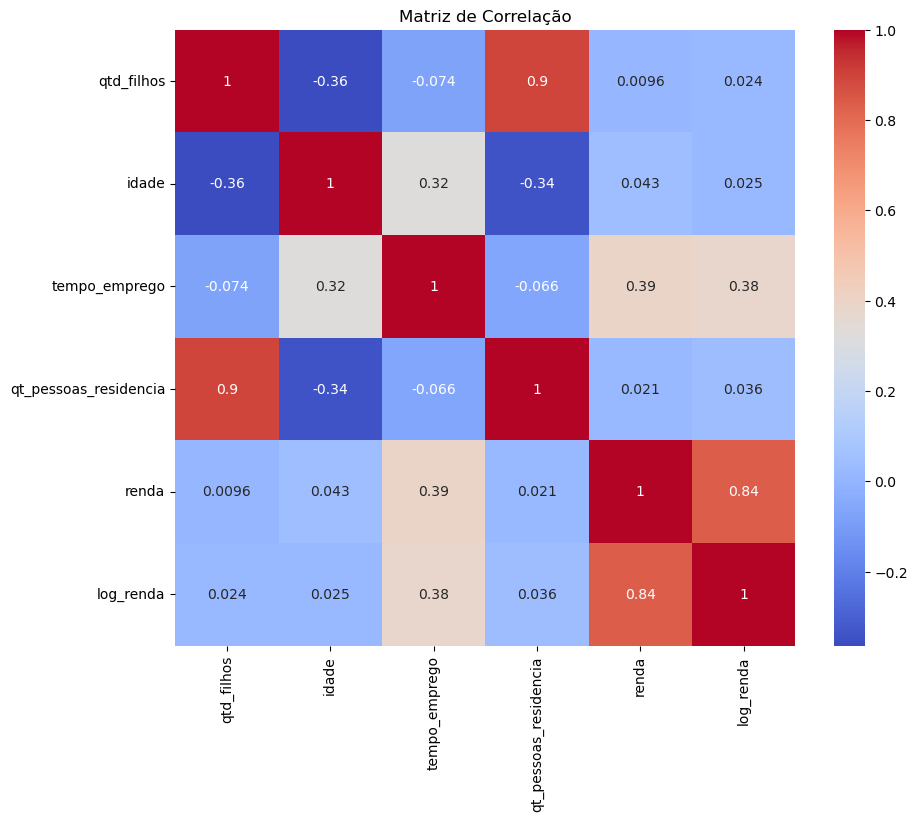

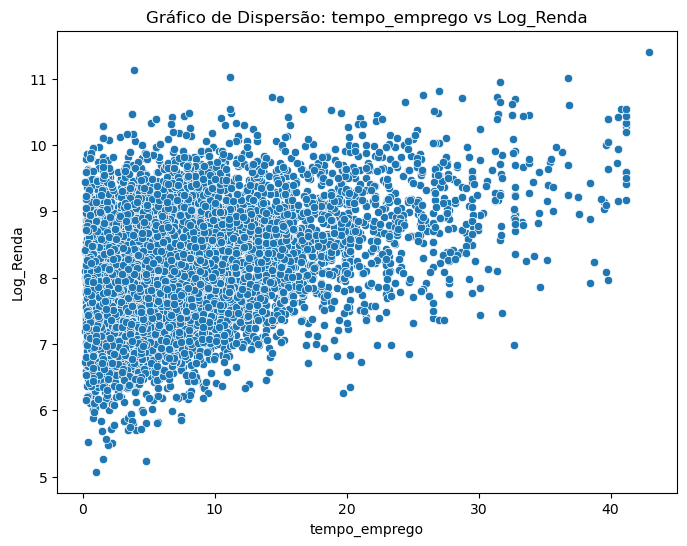

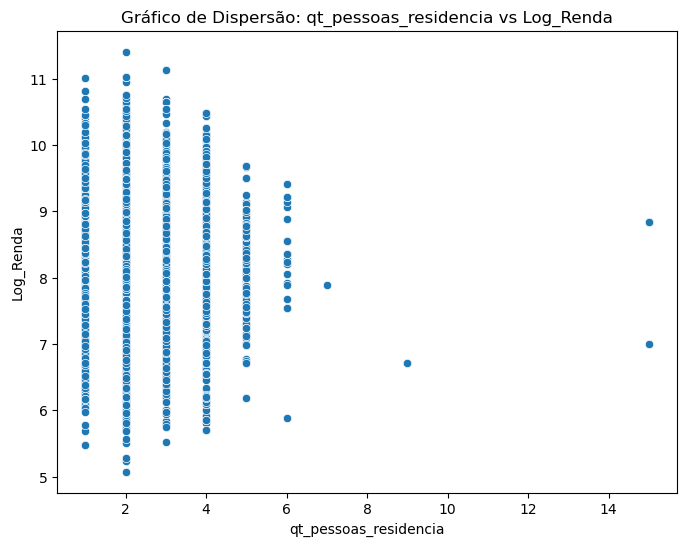

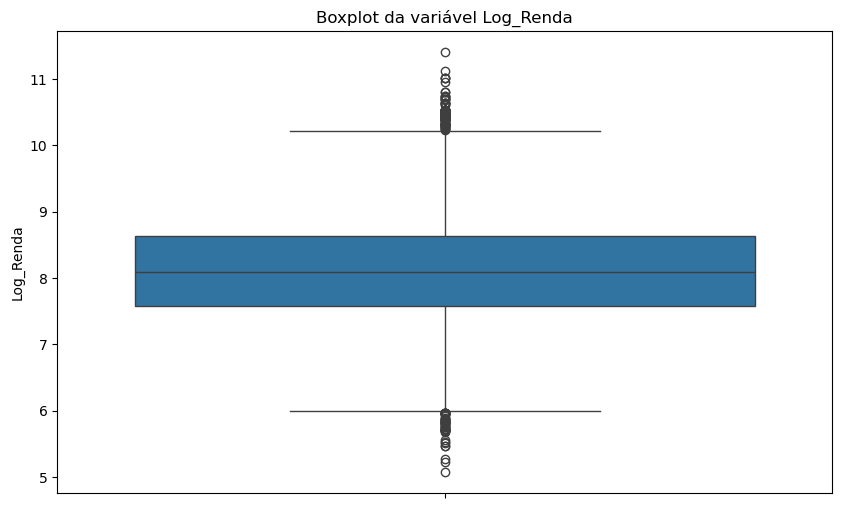

As duas variáveis mais correlacionadas com log_renda são: tempo_emprego e qt_pessoas_residencia


In [45]:
# Calcular o logaritmo da variável 'renda'
df_corr['log_renda'] = np.log(df_corr['renda'])

# Visualizar as primeiras linhas do dataframe para conferir
print(df_corr.head())

# Matriz de dispersão (pairplot) com 'log_renda'
sns.pairplot(df_corr, vars=['log_renda'] + [col for col in df_corr.columns if col != 'renda'])
plt.show()

# Matriz de correlação com 'log_renda'
correlation_matrix = df_corr.corr()

# Plotar a matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação')
plt.show()

# Identificar as duas variáveis mais correlacionadas com 'log_renda'
top_correlations = correlation_matrix['log_renda'].abs().sort_values(ascending=False)
top_variables = top_correlations.index[2:4]  # As duas variáveis mais correlacionadas (excluindo 'log_renda' própria)

# Gráfico de dispersão para as duas variáveis mais correlacionadas com 'log_renda'
for var in top_variables:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_corr, x=var, y='log_renda')
    plt.title(f'Gráfico de Dispersão: {var} vs Log_Renda')
    plt.xlabel(var)
    plt.ylabel('Log_Renda')
    plt.show()

# Criar o boxplot da variável 'log_renda'
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_corr['log_renda'])
plt.title('Boxplot da variável Log_Renda')
plt.ylabel('Log_Renda')
plt.show()

# Mostrar as duas variáveis mais correlacionadas com 'log_renda'
print(f"As duas variáveis mais correlacionadas com log_renda são: {top_variables[0]} e {top_variables[1]}")

Com o log da variável renda, houve uma menor dispersão dos dados. Entretanto, as variáveis que apresentaram maior correlação foram tempo de emprego e quantidade de pessoas na residência

5) A aplicação do LOG você acha que melhorou ou piorou a análise?

Sim. Ajudou a ter uma melhor visualização da correlação entre tempo de emprego e renda, ao aplicar log na variável renda.